In [ ]:
import numpy as np
import plotly.express as px
from sklearn.datasets import make_swiss_roll
import umap.umap_ as umap
from sklearn.manifold import TSNE
# -----------------------------
# Generate Swiss Roll
# -----------------------------
n_samples = 3000
X, t = make_swiss_roll(n_samples=n_samples, noise=0.0)

# Normalize t for clean color mapping
t_norm = (t - t.min()) / (t.max() - t.min())

# -----------------------------
# 3D Plotly Swiss Roll
# -----------------------------
fig_3d = px.scatter_3d(
    x=X[:, 0],
    y=X[:, 1],
    z=X[:, 2],
    color=t_norm,
    color_continuous_scale="Viridis",
    title="Swiss Roll (3D)",
    labels={"color": "Roll Parameter"},
)

fig_3d.update_traces(marker=dict(size=3))
fig_3d.update_layout(
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
    ),
    template="plotly_white",
)

fig_3d.show()

# -----------------------------
# UMAP Dimensionality Reduction
# -----------------------------
reducer = TSNE(
    n_components=2,
    perplexity=15,   # roughly analogous to n_neighbors
    random_state=42,
    init="random",   # or "pca"
    learning_rate="auto"
)

X_Umap = reducer.fit_transform(X)

# -----------------------------
# 2D Plotly UMAP Result
# -----------------------------
fig_2d = px.scatter(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    color=t_norm,
    color_continuous_scale="Viridis",
    title="UMAP Unfolding of Swiss Roll",
    labels={
        "x": "UMAP-1",
        "y": "UMAP-2",
        "color": "Roll Parameter",
    },
)

fig_2d.update_traces(marker=dict(size=4))
fig_2d.update_layout(
    template="plotly_white",
    xaxis=dict(scaleanchor="y", scaleratio=1),
)

fig_2d.show()


/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_76078/2158924094.py:24: UserWarning:

The figure layout has changed to tight



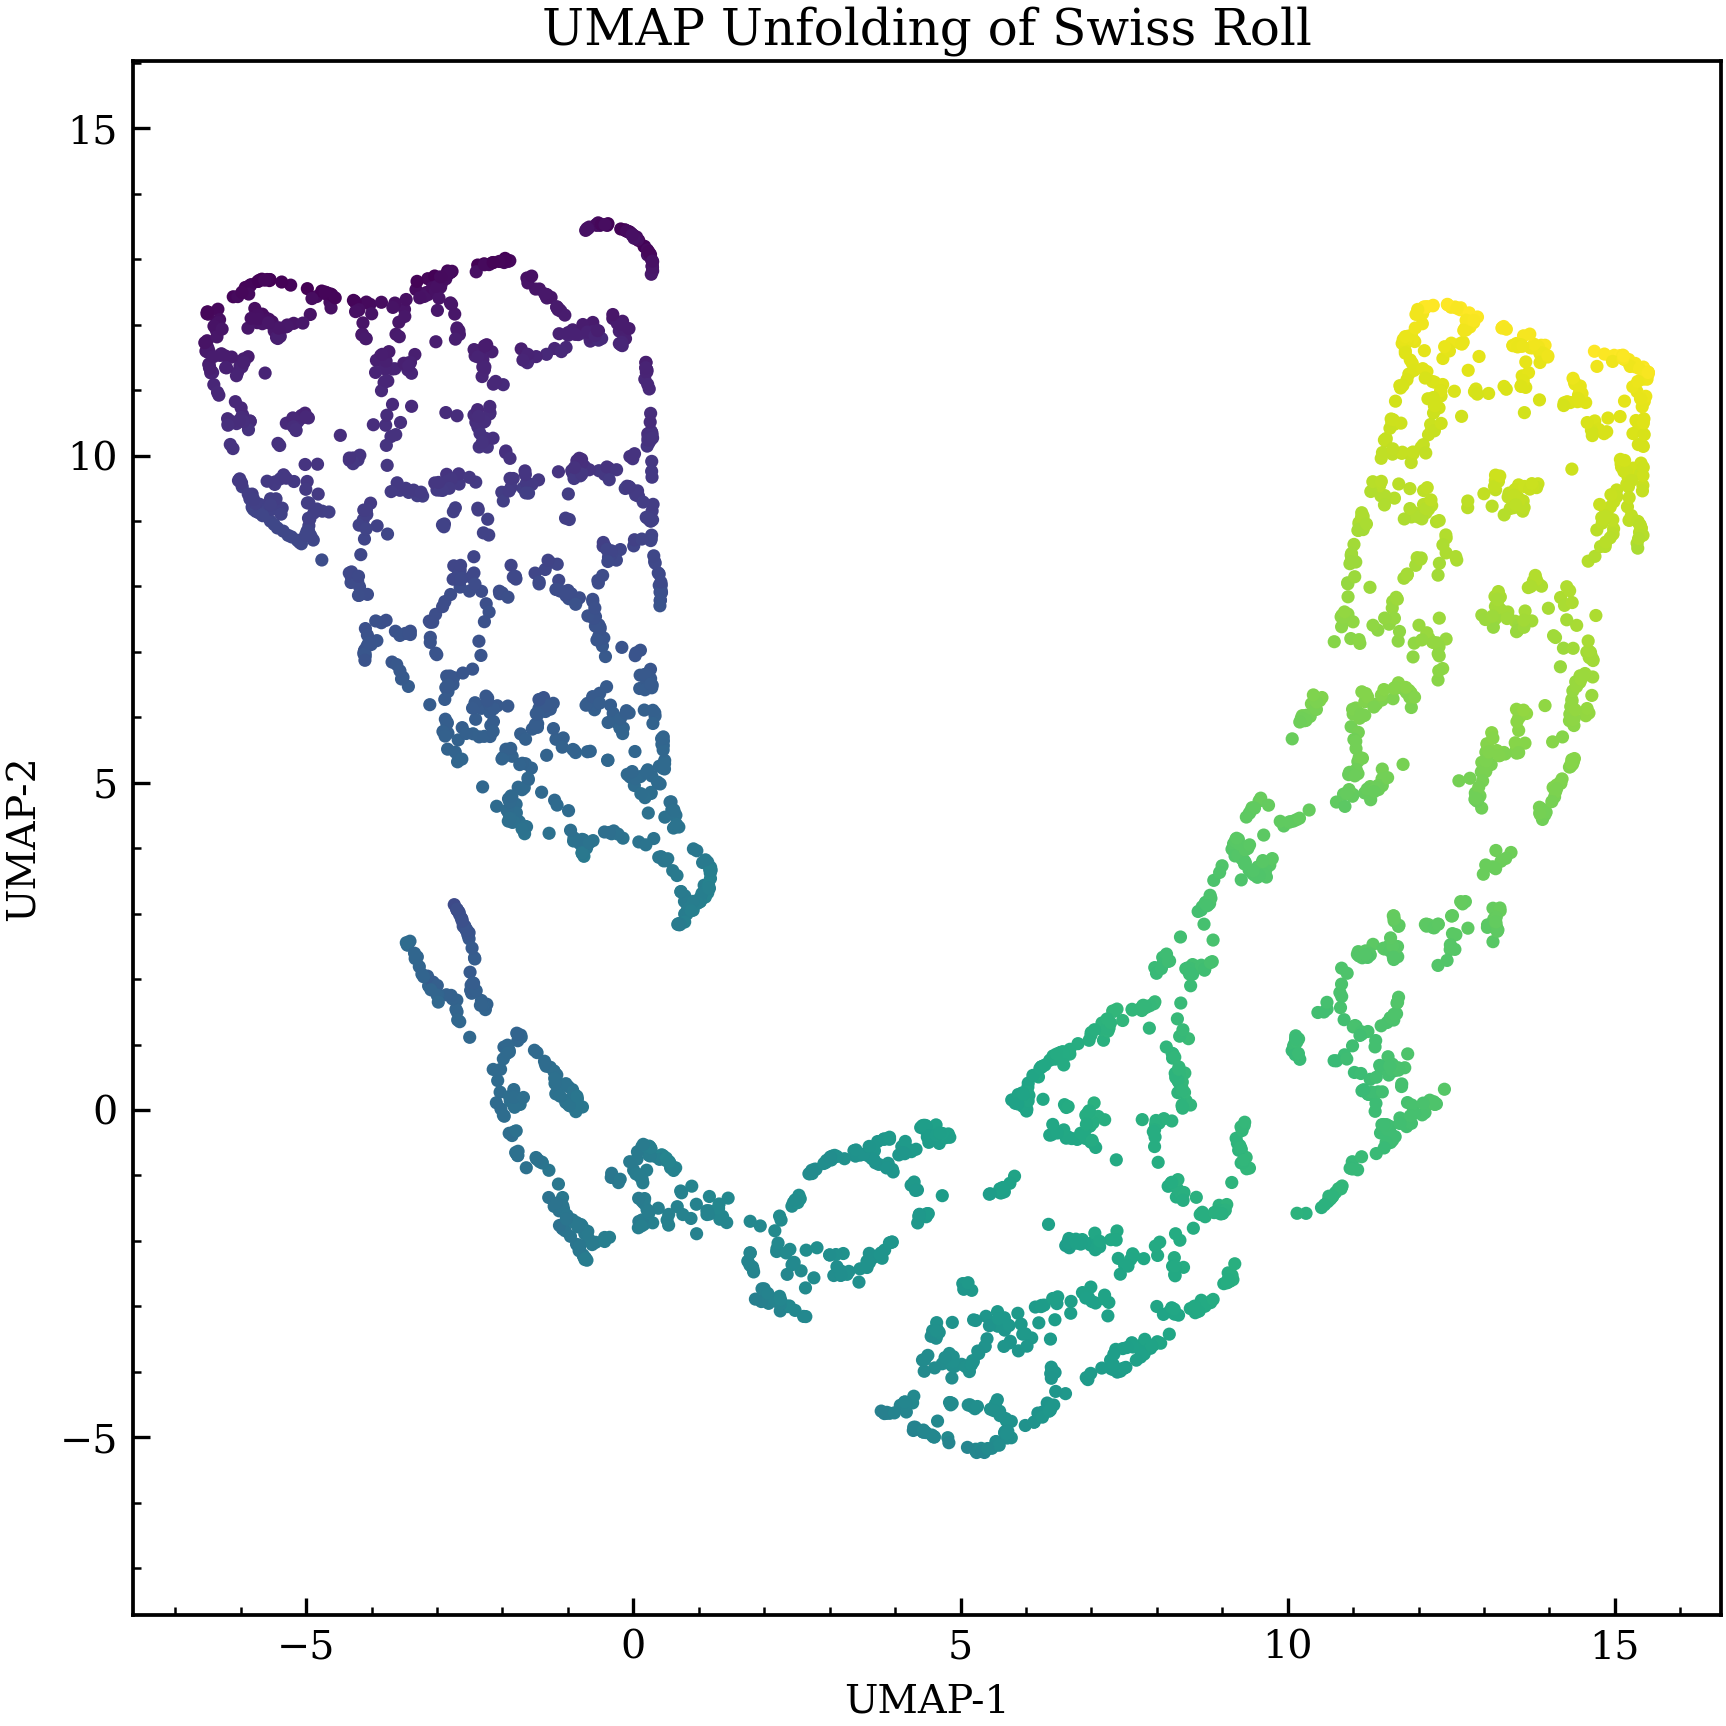

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.style.use("/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/prl.mplstyle")

sc = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=t_norm,
    cmap="viridis",
    s=10,
    linewidths=0,
)

plt.axis("equal")

# Axis labels
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.title("UMAP Unfolding of Swiss Roll", fontsize=12)


plt.tight_layout()
plt.show()
